<a href="https://colab.research.google.com/github/rameshavinash94/Cardiovascular-Detection-using-ECG-images/blob/main/Merging_Scaled_1D_%26_Trying_Different_CLassification_ML_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import os 
from natsort import natsorted
import joblib

### **WORKING ON COMBING MULTIPLE LEAD FILES**

In [3]:
#creating list to store file_names
NORMAL_=[]
MI_=[]
PMI_=[]
HB_=[]

normal = r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\NORMAL'
abnormal = r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\AHB'
MI = r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\MI'
MI_history = r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\PM'

Types_ECG = {'normal':normal,'Abnormal_hear_beat':abnormal,'MI':MI,'History_MI':MI_history}

for types,folder in Types_ECG.items():
  for files in os.listdir(folder):
    if types=='normal':
      NORMAL_.append(files)
    elif types=='Abnormal_hear_beat':
      HB_.append(files)
    elif types=='MI':
      MI_.append(files)
    elif types=='History_MI':
      PMI_.append(files)

In [4]:
NORMAL_ = natsorted(NORMAL_)
NORMAL_

['scaled_data_1D_1.csv',
 'scaled_data_1D_2.csv',
 'scaled_data_1D_3.csv',
 'scaled_data_1D_4.csv',
 'scaled_data_1D_5.csv',
 'scaled_data_1D_6.csv',
 'scaled_data_1D_7.csv',
 'scaled_data_1D_8.csv',
 'scaled_data_1D_9.csv',
 'scaled_data_1D_10.csv',
 'scaled_data_1D_11.csv',
 'scaled_data_1D_12.csv',
 'scaled_data_1D_13.csv']

In [5]:
MI_ = natsorted(MI_)
MI_

['scaled_data_1D_1.csv',
 'scaled_data_1D_2.csv',
 'scaled_data_1D_3.csv',
 'scaled_data_1D_4.csv',
 'scaled_data_1D_5.csv',
 'scaled_data_1D_6.csv',
 'scaled_data_1D_7.csv',
 'scaled_data_1D_8.csv',
 'scaled_data_1D_9.csv',
 'scaled_data_1D_10.csv',
 'scaled_data_1D_11.csv',
 'scaled_data_1D_12.csv',
 'scaled_data_1D_13.csv']

In [6]:
PMI_ = natsorted(PMI_)
PMI_

['scaled_data_1D_1.csv',
 'scaled_data_1D_2.csv',
 'scaled_data_1D_3.csv',
 'scaled_data_1D_4.csv',
 'scaled_data_1D_5.csv',
 'scaled_data_1D_6.csv',
 'scaled_data_1D_7.csv',
 'scaled_data_1D_8.csv',
 'scaled_data_1D_9.csv',
 'scaled_data_1D_10.csv',
 'scaled_data_1D_11.csv',
 'scaled_data_1D_12.csv',
 'scaled_data_1D_13.csv']

In [7]:
HB_ = natsorted(HB_)
HB_

['scaled_data_1D_1.csv',
 'scaled_data_1D_2.csv',
 'scaled_data_1D_3.csv',
 'scaled_data_1D_4.csv',
 'scaled_data_1D_5.csv',
 'scaled_data_1D_6.csv',
 'scaled_data_1D_7.csv',
 'scaled_data_1D_8.csv',
 'scaled_data_1D_9.csv',
 'scaled_data_1D_10.csv',
 'scaled_data_1D_11.csv',
 'scaled_data_1D_12.csv',
 'scaled_data_1D_13.csv']

#### **COMBINED CSV OF EACH LEAD(1-12) FROM ALL IMAGES**

In [8]:
#loop over and create combined csv files for each leads.
for x in range(len(MI_)):
  df1=pd.read_csv(r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\NORMAL\\{}'.format(NORMAL_[x]))
  df2=pd.read_csv(r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\AHB\\{}'.format(HB_[x]))
  df3=pd.read_csv(r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\MI\\{}'.format(MI_[x]))
  df4=pd.read_csv(r'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\preprocessed_1d\PM\\{}'.format(PMI_[x]))
  final_df = pd.concat([df1,df2,df3,df4],ignore_index=True)
  final_df.to_csv('E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv\Combined_IDLead_{}.csv'.format(x+1))

<>:8: SyntaxWarning: invalid escape sequence '\C'
<>:8: SyntaxWarning: invalid escape sequence '\C'
C:\Users\kunal\AppData\Local\Temp\ipykernel_16592\3966445094.py:8: SyntaxWarning: invalid escape sequence '\C'
  final_df.to_csv('E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv\Combined_IDLead_{}.csv'.format(x+1))


In [9]:
#now reading just lead1
df=pd.read_csv('E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv\Combined_IDLead_1.csv')
df['Target'].unique()

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\kunal\AppData\Local\Temp\ipykernel_16592\3564825814.py:2: SyntaxWarning: invalid escape sequence '\C'
  df=pd.read_csv('E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv\Combined_IDLead_1.csv')


array(['No', 'HB', 'MI', 'PM'], dtype=object)

In [10]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [11]:
#convert Target column values as Numeric using ngroups
encode_target_label = df.groupby('Target').ngroup().rename("target").to_frame()
test_final  = df.merge(encode_target_label, left_index=True, right_index=True)
test_final.drop(columns=['Target'],inplace=True)
test_final

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,target
0,0.728449,0.680755,0.619010,0.645367,0.681570,0.732488,0.758448,0.750660,0.728282,0.707928,...,0.637260,0.664539,0.667226,0.637064,0.593287,0.545503,0.515049,0.563257,0.633581,2
1,0.957972,0.950695,0.941024,0.930501,0.913601,0.892244,0.868016,0.855127,0.835307,0.798640,...,0.778790,0.806883,0.818640,0.842472,0.866740,0.884152,0.897196,0.911293,0.922903,2
2,0.611084,0.661575,0.695790,0.741113,0.716666,0.595794,0.425022,0.286457,0.425022,0.611384,...,0.000000,0.042690,0.165850,0.363445,0.549460,0.539346,0.522272,0.491668,0.454949,2
3,0.839213,0.861690,0.866457,0.865756,0.855027,0.855606,0.845561,0.843187,0.846784,0.824438,...,0.789156,0.793622,0.787665,0.794515,0.796739,0.804063,0.809944,0.801814,0.777322,2
4,0.917753,0.924369,0.873765,0.791381,0.699513,0.604927,0.500312,0.446012,0.528910,0.634068,...,0.200676,0.300147,0.407225,0.507346,0.605953,0.699309,0.790334,0.856593,0.849957,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,0.874246,0.877014,0.864280,0.860505,0.871349,0.912404,0.958148,0.977826,0.956314,0.926773,...,0.908312,0.926328,0.898749,0.855709,0.823132,0.815458,0.818083,0.829300,0.822382,3
924,0.829815,0.832084,0.852396,0.909665,0.988242,1.000000,0.923323,0.821865,0.721302,0.612039,...,0.429721,0.531567,0.642137,0.742063,0.833042,0.814867,0.777622,0.760714,0.759294,3
925,0.469048,0.417983,0.362322,0.351995,0.391493,0.418305,0.440135,0.444598,0.460402,0.506810,...,0.408587,0.401864,0.387069,0.359590,0.325879,0.288894,0.293521,0.344504,0.399012,3
926,0.682510,0.682286,0.641051,0.620212,0.608210,0.576331,0.603596,0.645714,0.677964,0.720297,...,0.452247,0.450421,0.439278,0.439086,0.394417,0.441650,0.473909,0.539199,0.547146,3


#### **PERFORM DIMENSIONALITY REDUCTION JUST FOR CHECKING/UNDERSTANDING**

In [12]:
#just for testing
# Now Perform Dimensionality reduction (PCA) on that Dataframe and check
from sklearn.decomposition import PCA

#do PCA and choose componeents as 100
pca = PCA(n_components=100)
x_pca = pca.fit_transform(test_final.iloc[:,0:-1])
x_pca = pd.DataFrame(x_pca)

# Calculate the variance explained by priciple components
explained_variance = pca.explained_variance_ratio_
print('Variance of each component:', pca.explained_variance_ratio_)
print('\n Total Variance Explained:', round(sum(list(pca.explained_variance_ratio_))*100, 2))

#store the new pca generated dimensions in a dataframe
pca_df = pd.DataFrame(data = x_pca)
target = pd.Series(test_final['target'], name='target')
result_df = pd.concat([pca_df, target], axis=1)
result_df

Variance of each component: [1.76145888e-01 9.50265614e-02 6.99060614e-02 6.15960001e-02
 5.34876630e-02 4.23664893e-02 3.68320213e-02 3.38541791e-02
 3.00884979e-02 2.90396728e-02 2.64962509e-02 2.42272738e-02
 2.10221030e-02 1.99751559e-02 1.77321042e-02 1.63016802e-02
 1.53898622e-02 1.48412074e-02 1.33644825e-02 1.19674074e-02
 1.16813409e-02 1.05807650e-02 9.68875480e-03 9.47385060e-03
 8.65347748e-03 8.47506998e-03 7.93382172e-03 7.30163338e-03
 6.76380665e-03 6.36886390e-03 6.02004791e-03 5.46823032e-03
 5.31229911e-03 4.97821789e-03 4.74686092e-03 4.46081684e-03
 4.21254684e-03 4.01200243e-03 3.87246476e-03 3.52519084e-03
 3.37596894e-03 3.26978336e-03 3.08241145e-03 2.96423495e-03
 2.73419816e-03 2.50965698e-03 2.35335480e-03 2.25665349e-03
 2.20141761e-03 1.96782025e-03 1.74343954e-03 1.70982830e-03
 1.57456047e-03 1.53704487e-03 1.36768435e-03 1.33167096e-03
 1.26444173e-03 1.20053330e-03 1.18738749e-03 1.08864087e-03
 1.02824532e-03 9.11484783e-04 7.89962329e-04 7.59785111e

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,target
0,-1.018578,-1.148263,-0.589582,-0.193617,0.047950,-0.309400,0.161566,-0.478471,-0.972403,0.031832,...,-0.011854,0.003776,0.024620,0.012507,0.000721,-0.002123,0.007592,-0.064078,-0.029985,2
1,1.098692,-0.289832,-1.766388,-1.076165,-0.261201,-0.820446,0.474188,0.515238,-0.692389,-1.501606,...,0.017253,-0.060573,-0.007571,0.012780,0.001009,-0.044606,0.032526,-0.035213,0.001594,2
2,-0.275021,0.451289,0.106750,0.426415,0.066133,0.692474,-0.634894,0.035867,-0.815855,0.909473,...,-0.044885,0.042082,-0.028229,0.121092,-0.043878,0.020242,-0.019746,0.045978,0.006338,2
3,1.517085,-1.662693,-1.021167,-0.804267,-0.281985,0.518180,-0.355748,0.344235,0.910867,0.629517,...,-0.001025,-0.041649,0.016936,-0.049741,-0.040879,0.017117,-0.023803,0.027289,-0.032642,2
4,0.152840,1.046283,0.351278,-1.100381,-1.613642,1.484188,0.113277,0.251152,-0.179023,0.233104,...,0.009315,-0.054014,0.003166,0.029645,0.016648,0.003888,0.046211,-0.000230,-0.034465,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,1.321884,-2.153021,0.788596,1.304253,0.458186,-0.859346,0.069127,0.392796,-0.755732,0.584050,...,0.037030,-0.077444,-0.044216,-0.033395,0.006243,0.023808,-0.049348,-0.008341,0.011189,3
924,0.867163,0.040504,0.940680,-0.302648,-0.469672,-0.368255,-1.065579,-0.801522,-0.690113,-0.953008,...,-0.012776,0.092494,0.013751,-0.028601,-0.009622,-0.055485,-0.009607,-0.064148,-0.017955,3
925,-3.753012,-0.841636,-0.317393,0.296117,0.593769,-0.255474,0.057091,0.072048,-0.664386,0.837668,...,0.008718,0.005861,-0.003564,0.005755,-0.023387,-0.068262,0.024030,-0.004878,-0.017753,3
926,-0.603083,-0.126259,0.003433,-0.283612,0.169559,-0.156326,0.068399,0.184308,-0.461063,0.002047,...,-0.056539,-0.022985,-0.014649,-0.080486,-0.007354,-0.040090,-0.051603,0.020980,0.060768,3


In [13]:
result_df

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,target
0,-1.018578,-1.148263,-0.589582,-0.193617,0.047950,-0.309400,0.161566,-0.478471,-0.972403,0.031832,...,-0.011854,0.003776,0.024620,0.012507,0.000721,-0.002123,0.007592,-0.064078,-0.029985,2
1,1.098692,-0.289832,-1.766388,-1.076165,-0.261201,-0.820446,0.474188,0.515238,-0.692389,-1.501606,...,0.017253,-0.060573,-0.007571,0.012780,0.001009,-0.044606,0.032526,-0.035213,0.001594,2
2,-0.275021,0.451289,0.106750,0.426415,0.066133,0.692474,-0.634894,0.035867,-0.815855,0.909473,...,-0.044885,0.042082,-0.028229,0.121092,-0.043878,0.020242,-0.019746,0.045978,0.006338,2
3,1.517085,-1.662693,-1.021167,-0.804267,-0.281985,0.518180,-0.355748,0.344235,0.910867,0.629517,...,-0.001025,-0.041649,0.016936,-0.049741,-0.040879,0.017117,-0.023803,0.027289,-0.032642,2
4,0.152840,1.046283,0.351278,-1.100381,-1.613642,1.484188,0.113277,0.251152,-0.179023,0.233104,...,0.009315,-0.054014,0.003166,0.029645,0.016648,0.003888,0.046211,-0.000230,-0.034465,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,1.321884,-2.153021,0.788596,1.304253,0.458186,-0.859346,0.069127,0.392796,-0.755732,0.584050,...,0.037030,-0.077444,-0.044216,-0.033395,0.006243,0.023808,-0.049348,-0.008341,0.011189,3
924,0.867163,0.040504,0.940680,-0.302648,-0.469672,-0.368255,-1.065579,-0.801522,-0.690113,-0.953008,...,-0.012776,0.092494,0.013751,-0.028601,-0.009622,-0.055485,-0.009607,-0.064148,-0.017955,3
925,-3.753012,-0.841636,-0.317393,0.296117,0.593769,-0.255474,0.057091,0.072048,-0.664386,0.837668,...,0.008718,0.005861,-0.003564,0.005755,-0.023387,-0.068262,0.024030,-0.004878,-0.017753,3
926,-0.603083,-0.126259,0.003433,-0.283612,0.169559,-0.156326,0.068399,0.184308,-0.461063,0.002047,...,-0.056539,-0.022985,-0.014649,-0.080486,-0.007354,-0.040090,-0.051603,0.020980,0.060768,3


#### **TRYING DIFFERENT ML MODELS ON A SINGLE LEAD(EX : 1) POST DIMENSIONALITY REDUCTION**

##### **KNN**

In [14]:
# Import the necessary modules for ML model
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Setup the pipeline steps:
steps = [('knn', KNeighborsClassifier())]
        
# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

# have paased less range value of hyperparamter since i'm using free tier version of google colab.
k_range = list(range(1, 9))
parameters = dict(knn__n_neighbors=k_range)

#input
X = result_df.iloc[:,0:-1]

#target
y=result_df.iloc[:,-1]

# Create train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)

#increasing cv score takes lot of time in gooogle colab, so kept it just 2.
cv = GridSearchCV(pipeline,parameters,cv=2)

cv.fit(X_train,y_train)

# Predict the labels of the test set: y_pred
y_pred = cv.predict(X_test)

Knn_Accuracy = cv.score(X_test, y_test)

# Compute and print metrics
print("Accuracy: {}".format(Knn_Accuracy))
print(classification_report(y_test, y_pred))
print("Tuned Model Parameters: {}".format(cv.best_params_))

Accuracy: 0.782258064516129
              precision    recall  f1-score   support

           0       0.87      0.63      0.73       105
           1       0.91      0.91      0.91        94
           2       0.72      0.88      0.79       112
           3       0.63      0.67      0.65        61

    accuracy                           0.78       372
   macro avg       0.78      0.77      0.77       372
weighted avg       0.80      0.78      0.78       372

Tuned Model Parameters: {'knn__n_neighbors': 1}


##### **LOGISTIC REGRESSION**

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Setup the pipeline steps:
steps = [('lr', LogisticRegression())]
        
# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

#input
X = result_df.iloc[:,0:-1]

#target
y=result_df.iloc[:,-1]

#parameters for gridsearchcv if we increase range of entries from 5 to higher value, we can get greater accurange
c_space = np.logspace(-4, 4, 3)
parameters = {'lr__C': c_space,'lr__penalty': ['l2']} 

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)

#call GridSearchCV and set crossvalscore to 2
cv = GridSearchCV(pipeline,parameters,cv=2)

cv.fit(X_train,y_train)

# Predict the labels of the test set: y_pred
y_pred = cv.predict(X_test)
LR_Accuracy = cv.score(X_test, y_test)

C:\Users\kunal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\kunal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stab

In [16]:
# Compute and print metrics
print("Accuracy: {}".format(LR_Accuracy))
print(classification_report(y_test, y_pred))
print("Tuned Model Parameters: {}".format(cv.best_params_))

Accuracy: 0.5456989247311828
              precision    recall  f1-score   support

           0       0.36      0.33      0.35       105
           1       0.73      0.91      0.81        94
           2       0.57      0.58      0.58       112
           3       0.39      0.28      0.32        61

    accuracy                           0.55       372
   macro avg       0.51      0.53      0.51       372
weighted avg       0.52      0.55      0.53       372

Tuned Model Parameters: {'lr__C': np.float64(10000.0), 'lr__penalty': 'l2'}


##### **SVM**

In [17]:
# Import the necessary modules for ML model
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Setup the pipeline
steps = [('SVM', SVC())]

pipeline = Pipeline(steps)

#input
X = result_df.iloc[:,0:-1]

#target
y=result_df.iloc[:,-1]

# Specify the hyperparameter space, if we increase the penalty(c) and gamma value the accurancy can be increased.
#since it takes lots of time in google colab provided only a single value
parameters = {'SVM__C':[10],'SVM__gamma':[1]}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=21)

cv = GridSearchCV(pipeline,parameters,cv=3)
cv.fit(X_train,y_train)

y_pred = cv.predict(X_test)
SVM_Accuracy = cv.score(X_test, y_test)

# Compute and print metrics
SVM_Accuracy=cv.score(X_test, y_test)

print("Accuracy: {}".format(SVM_Accuracy))
print(classification_report(y_test, y_pred))

Accuracy: 0.8225806451612904
              precision    recall  f1-score   support

           0       0.58      1.00      0.74        93
           1       1.00      1.00      1.00        99
           2       1.00      0.61      0.76       117
           3       1.00      0.68      0.81        63

    accuracy                           0.82       372
   macro avg       0.90      0.82      0.83       372
weighted avg       0.90      0.82      0.83       372



#### **NOW COMBINING ALL 12 LEADS INTO A SINGLE CSV FILE AND THEN PERFROM MODEL ANALYSIS**

In [18]:
#lets try combining all 12 leads in a single csv
location= 'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv'
for files in natsorted(os.listdir(location)):
  if files.endswith(".csv") and not files.endswith("13.csv"):
    if files!='Combined_IDLead_1.csv':
      df=pd.read_csv('E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv\{}'.format(files))
      df.drop(columns=['Unnamed: 0'],inplace=True)
      test_final=pd.concat([test_final,df],axis=1,ignore_index=True)
      test_final.drop(columns=test_final.columns[-1],axis=1,inplace=True)

#drop the target column
test_final.drop(columns=[255],axis=1,inplace=True)
test_final

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:6: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:6: SyntaxWarning: invalid escape sequence '\C'
C:\Users\kunal\AppData\Local\Temp\ipykernel_16592\2357361447.py:2: SyntaxWarning: invalid escape sequence '\C'
  location= 'E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv'
C:\Users\kunal\AppData\Local\Temp\ipykernel_16592\2357361447.py:6: SyntaxWarning: invalid escape sequence '\C'
  df=pd.read_csv('E:\Cardiovascular-Disease-Detection-From-ECG-Images-main\Cardiovascular-Disease-Detection-From-ECG-Images-main\Combined1d_csv\{}'.format(files))


,0,1,2,3,4,5,6,7,8,9,...,3051,3052,3053,3054,3055,3056,3057,3058,3059,3060
0,0.728449,0.680755,0.619010,0.645367,0.681570,0.732488,0.758448,0.750660,0.728282,0.707928,...,0.864067,0.849256,0.854949,0.861380,0.875514,0.868763,0.847450,0.805689,0.751761,0.702102
1,0.957972,0.950695,0.941024,0.930501,0.913601,0.892244,0.868016,0.855127,0.835307,0.798640,...,0.925865,0.928285,0.946033,0.947274,0.946394,0.936536,0.920869,0.910320,0.905436,0.876942
2,0.611084,0.661575,0.695790,0.741113,0.716666,0.595794,0.425022,0.286457,0.425022,0.611384,...,0.170137,0.166206,0.207633,0.258184,0.286993,0.304742,0.325659,0.361189,0.451946,0.543373
3,0.839213,0.861690,0.866457,0.865756,0.855027,0.855606,0.845561,0.843187,0.846784,0.824438,...,0.880043,0.883833,0.870995,0.861323,0.864892,0.863552,0.839506,0.805486,0.801828,0.826618
4,0.917753,0.924369,0.873765,0.791381,0.699513,0.604927,0.500312,0.446012,0.528910,0.634068,...,0.400774,0.380920,0.439510,0.505257,0.561538,0.577997,0.566082,0.547642,0.538735,0.527560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,0.874246,0.877014,0.864280,0.860505,0.871349,0.912404,0.958148,0.977826,0.956314,0.926773,...,0.785103,0.676795,0.579054,0.476613,0.458748,0.565470,0.681896,0.792646,0.871660,0.872789
924,0.829815,0.832084,0.852396,0.909665,0.988242,1.000000,0.923323,0.821865,0.721302,0.612039,...,0.913404,0.968015,0.992614,0.945789,0.876660,0.808906,0.741645,0.736615,0.797729,0.855637
925,0.469048,0.417983,0.362322,0.351995,0.391493,0.418305,0.440135,0.444598,0.460402,0.506810,...,0.730354,0.697465,0.714527,0.745605,0.754952,0.755059,0.755059,0.755093,0.759093,0.767555
926,0.682510,0.682286,0.641051,0.620212,0.608210,0.576331,0.603596,0.645714,0.677964,0.720297,...,0.860939,0.824976,0.783459,0.761391,0.741917,0.770631,0.802701,0.821503,0.846300,0.858795


In [19]:
#write the final file to csv
test_final.to_csv('final_1D.csv',header=False,index=False)

#### **TEST DIMENSIONALITY REDUCTION EXPLAINED VARIANCE ON  THE DATA**

In [20]:
# Now Perform Dimensionality reduction (PCA) on that Dataframe and check
from sklearn.decomposition import PCA

#do PCA and choose componeents as 400
pca = PCA(n_components=400)
x_pca = pca.fit_transform(test_final)
x_pca = pd.DataFrame(x_pca)

# Calculate the variance explained by priciple components
explained_variance = pca.explained_variance_ratio_
print('Variance of each component:', pca.explained_variance_ratio_)
print('\n Total Variance Explained:', round(sum(list(pca.explained_variance_ratio_))*100, 2))

#store the new pca generated dimensions in a dataframe
#store the new pca generated dimensions in a dataframe
pca_df = pd.DataFrame(data = x_pca)
target = pd.Series(result_df.iloc[:,-1], name='target')
final_result_df = pd.concat([pca_df, target], axis=1)
final_result_df

Variance of each component: [8.04649534e-02 4.68818003e-02 3.76212504e-02 2.94708618e-02
 2.57031130e-02 2.32574514e-02 2.14376788e-02 2.04315151e-02
 1.94482863e-02 1.79877408e-02 1.64766264e-02 1.53241665e-02
 1.50689862e-02 1.41398267e-02 1.36330466e-02 1.33375324e-02
 1.26355566e-02 1.25577001e-02 1.16968257e-02 1.11671338e-02
 1.07975552e-02 1.06183806e-02 1.03402122e-02 1.01248410e-02
 9.73197948e-03 9.25504395e-03 9.16367637e-03 8.76267060e-03
 8.54270112e-03 8.20665462e-03 8.07642149e-03 7.90742343e-03
 7.54929819e-03 7.21938018e-03 7.07604659e-03 6.89135251e-03
 6.80575532e-03 6.71875790e-03 6.38252148e-03 6.33951897e-03
 6.10254734e-03 5.94560955e-03 5.76371295e-03 5.71788829e-03
 5.55354810e-03 5.42316932e-03 5.35640711e-03 5.08429353e-03
 5.03302777e-03 4.96811576e-03 4.87696491e-03 4.63686128e-03
 4.55349933e-03 4.45390625e-03 4.31579996e-03 4.28316592e-03
 4.17213140e-03 4.12346241e-03 4.09072049e-03 3.99349122e-03
 3.92129459e-03 3.81982060e-03 3.78116652e-03 3.73307150e

,0,1,2,3,4,5,6,7,8,9,...,391,392,393,394,395,396,397,398,399,target
0,0.457260,-0.433402,0.951313,-0.118767,0.372034,1.917341,0.503248,0.996278,-2.306744,-1.294890,...,-0.056082,-0.024045,0.052601,0.154959,0.074600,0.138087,-0.038995,-0.007807,0.119502,2
1,1.482871,3.923833,-1.001672,1.151786,-0.105634,0.935446,0.061538,-1.340459,-4.633610,-0.483502,...,0.277358,0.089653,-0.025043,-0.118594,-0.021262,0.120232,0.067804,-0.033501,0.124539,2
2,-6.524849,0.064380,2.177830,-0.744632,-3.160053,-2.079289,1.991373,-2.629458,1.251710,1.656291,...,-0.063566,0.118223,0.044333,0.038904,0.026338,-0.065339,-0.089853,0.161430,-0.013083,2
3,4.626337,0.901579,1.351431,-1.767117,0.870166,2.210025,3.710694,1.478115,-2.406238,-3.754295,...,-0.015876,0.097511,-0.051405,-0.101764,0.092100,-0.133936,-0.026443,0.067916,-0.008878,2
4,3.863027,2.805259,0.428457,-0.482452,0.231498,1.977056,1.605510,0.603866,-1.312170,3.553396,...,0.072523,-0.054796,-0.042024,-0.132510,0.205588,0.046774,-0.104020,0.121419,-0.089041,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,3.365774,2.530997,0.781861,0.567793,1.960806,2.319130,3.632739,-2.072028,0.318600,1.423024,...,-0.088798,0.090042,-0.041577,-0.053392,-0.097186,-0.006027,0.237294,-0.121677,0.000343,3
924,6.340754,-0.634164,3.259888,2.894988,2.625952,-1.435685,1.570297,-0.456509,-0.855480,0.523852,...,0.114307,0.054648,0.186377,-0.142732,-0.074375,0.030806,0.202629,-0.064385,0.034029,3
925,2.106097,-4.489429,-4.740686,2.521037,1.810682,1.252919,-0.925497,-2.413092,-0.426080,-2.335654,...,-0.067115,-0.034074,-0.024820,-0.123323,0.055688,-0.147756,-0.175265,0.044838,0.022303,3
926,1.091978,-7.063249,-2.692234,-0.543705,-0.443376,1.028903,-1.749000,-0.469497,-0.575796,-1.181286,...,-0.092972,0.246077,0.070709,0.021262,-0.114874,-0.062432,0.245654,0.077069,-0.005084,3


In [21]:
#save to dimensionally reduced csv file
final_result_df.to_csv("pca_final.csv")

In [22]:
import joblib
#save the PCA model
joblib_file='PCA_ECG.pkl'
joblib.dump(pca,joblib_file)

['PCA_ECG.pkl']

#### **TRYING DIFFERENT ML MODELS ON THE ALL 12 LEADS COMBINED FILE WITHOUT DIMENSIONALITY REDUCTION**

##### **KNN**

In [23]:
# Import the necessary modules for ML model
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Setup the pipeline steps:
steps = [('knn', KNeighborsClassifier())]
        
# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

# have paased less range value of hyperparamter since i'm using free tier version of google colab.
k_range = list(range(1, 30))
parameters = dict(knn__n_neighbors=k_range)

#input
X = final_result_df.iloc[:,:-1]

#target
y=final_result_df.iloc[:,-1]

# Create train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)

#increasing cv score takes lot of time in gooogle colab, so kept it just 2.
cv = GridSearchCV(pipeline,parameters,cv=2)

cv.fit(X_train,y_train)

# Predict the labels of the test set: y_pred
y_pred = cv.predict(X_test)

Knn_Accuracy = cv.score(X_test, y_test)

# Compute and print metrics
print("Accuracy: {}".format(Knn_Accuracy))
print(classification_report(y_test, y_pred))
print("Tuned Model Parameters: {}".format(cv.best_params_))

Accuracy: 0.793010752688172
              precision    recall  f1-score   support

           0       0.92      0.65      0.76       105
           1       0.95      0.91      0.93        94
           2       0.70      0.86      0.77       112
           3       0.65      0.74      0.69        61

    accuracy                           0.79       372
   macro avg       0.80      0.79      0.79       372
weighted avg       0.81      0.79      0.79       372

Tuned Model Parameters: {'knn__n_neighbors': 1}


##### **LOGISTIC REGRESSION**

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Setup the pipeline steps:
steps = [('lr', LogisticRegression())]
        
# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

#input
X = final_result_df.iloc[:,:-1]

#target
y=final_result_df.iloc[:,-1]

#parameters for gridsearchcv
c_space = np.logspace(-4, 4, 10)
parameters = {'lr__C': c_space,'lr__penalty': ['l2']} 

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)

#call GridSearchCV and set crossvalscore to 2
cv = GridSearchCV(pipeline,parameters,cv=2)

cv.fit(X_train,y_train)

# Predict the labels of the test set: y_pred
y_pred = cv.predict(X_test)
LR_Accuracy = cv.score(X_test, y_test)

In [25]:
# Compute and print metrics
print("Accuracy: {}".format(LR_Accuracy))
print(classification_report(y_test, y_pred))
print("Tuned Model Parameters: {}".format(cv.best_params_))

Accuracy: 0.7768817204301075
              precision    recall  f1-score   support

           0       0.83      0.57      0.68       105
           1       0.83      0.91      0.87        94
           2       0.82      0.86      0.84       112
           3       0.59      0.77      0.67        61

    accuracy                           0.78       372
   macro avg       0.77      0.78      0.76       372
weighted avg       0.79      0.78      0.77       372

Tuned Model Parameters: {'lr__C': np.float64(0.3593813663804626), 'lr__penalty': 'l2'}


##### **SVM**

In [26]:
# Import the necessary modules for ML model
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Setup the pipeline
steps = [('SVM', SVC())]

pipeline = Pipeline(steps)

#input
X = final_result_df.iloc[:,:-1]

#target
y=final_result_df.iloc[:,-1]

# Specify the hyperparameter space, if we increase the penalty(c) and gamma value the accurancy can be increased.
#since it takes lots of time in google colab provided only a single value
parameters = {'SVM__C':[1, 10, 100],
              'SVM__gamma':[0.1, 0.01]}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,random_state=21)

cv = GridSearchCV(pipeline,parameters,cv=3)
cv.fit(X_train,y_train)

y_pred = cv.predict(X_test)
SVM_Accuracy = cv.score(X_test, y_test)

# Compute and print metrics
SVM_Accuracy=cv.score(X_test, y_test)

print("Accuracy: {}".format(SVM_Accuracy))
print(classification_report(y_test, y_pred))
print("Tuned Model Parameters: {}".format(cv.best_params_))

Accuracy: 0.9051724137931034
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       119
           1       1.00      1.00      1.00       125
           2       0.91      0.89      0.90       140
           3       0.93      0.78      0.84        80

    accuracy                           0.91       464
   macro avg       0.91      0.89      0.90       464
weighted avg       0.91      0.91      0.91       464

Tuned Model Parameters: {'SVM__C': 10, 'SVM__gamma': 0.01}


### **XGBOOST**

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

In [29]:
# evaluate predictions
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: {}".format(accuracy))
print(classification_report(y_test, y_pred))

Accuracy: 0.8728448275862069
              precision    recall  f1-score   support

           0       0.81      0.74      0.78       119
           1       0.98      1.00      0.99       125
           2       0.83      0.91      0.87       140
           3       0.85      0.80      0.83        80

    accuracy                           0.87       464
   macro avg       0.87      0.86      0.87       464
weighted avg       0.87      0.87      0.87       464



#### **SAVING A VERY BASIC ML MODEL AND USING IT ON REALTIME PIPELINE TO CHECK WORKING**

In [30]:
# Import the necessary modules for ML model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib
#input
X = final_result_df.iloc[:,:-1]
#target
y=final_result_df.iloc[:,-1]

# Create train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4,random_state=42)

knn =  KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train,y_train)

joblib_file='knn_model_test.pkl'
joblib.dump(knn,joblib_file)

['knn_model_test.pkl']

In [31]:
# Import the necessary modules for ML model
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

#input
X = pd.read_csv('final_1D.csv',header=None)

#target
y=final_result_df.iloc[:,-1]

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.5,random_state=21)

svm=SVC(C=10,gamma=0.01)

svm.fit(X_train,y_train)

joblib_file='svm_model_test.pkl'
joblib.dump(svm,joblib_file)

['svm_model_test.pkl']

### **ENSEMBLE**

In [32]:
# Importing required modules
from sklearn import linear_model, tree, ensemble
from sklearn.naive_bayes import GaussianNB
import xgboost
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
import pickle

In [33]:
#input
X = final_result_df.iloc[:,0:-1]

#target
y=final_result_df.iloc[:,-1]

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [34]:
# Stacking of ML Models
eclf = VotingClassifier(estimators=[ 
    ('SVM', SVC(probability=True)),
    ('knn', KNeighborsClassifier()),
    ('rf', ensemble.RandomForestClassifier()),
    ('bayes',GaussianNB()),
    ('logistic',LogisticRegression()),
    ], voting='soft')

In [35]:
# Hyperparameter Tuning using gridSearch
params = {'SVM__C':[1, 10, 100],
          'SVM__gamma':[0.1, 0.01],
          'knn__n_neighbors': [1,3,5],
          'rf__n_estimators':[300, 400],
          }

grid = GridSearchCV(estimator=eclf, param_grid=params, cv=5)
voting_clf = grid.fit(X_train, y_train)

print(grid.best_params_)
y_pred = voting_clf.predict(X_test)

# Compute and print metrics
Voting_Accuracy=voting_clf.score(X_test, y_test)

print("Accuracy: {}".format(Voting_Accuracy))
print(classification_report(y_test, y_pred))
print(voting_clf.best_params_)

{'SVM__C': 10, 'SVM__gamma': 0.1, 'knn__n_neighbors': 5, 'rf__n_estimators': 300}
Accuracy: 0.9247311827956989
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        80
           1       1.00      1.00      1.00        72
           2       0.86      0.92      0.89        79
           3       0.84      0.79      0.82        48

    accuracy                           0.92       279
   macro avg       0.92      0.91      0.92       279
weighted avg       0.93      0.92      0.92       279

{'SVM__C': 10, 'SVM__gamma': 0.1, 'knn__n_neighbors': 5, 'rf__n_estimators': 300}


In [38]:
# open a file, where you want to store the data
file = open('Heart_Disease_Prediction_using_ECG.pkl(4)', 'wb')
# dump information to that file
pickle.dump(voting_clf, file)

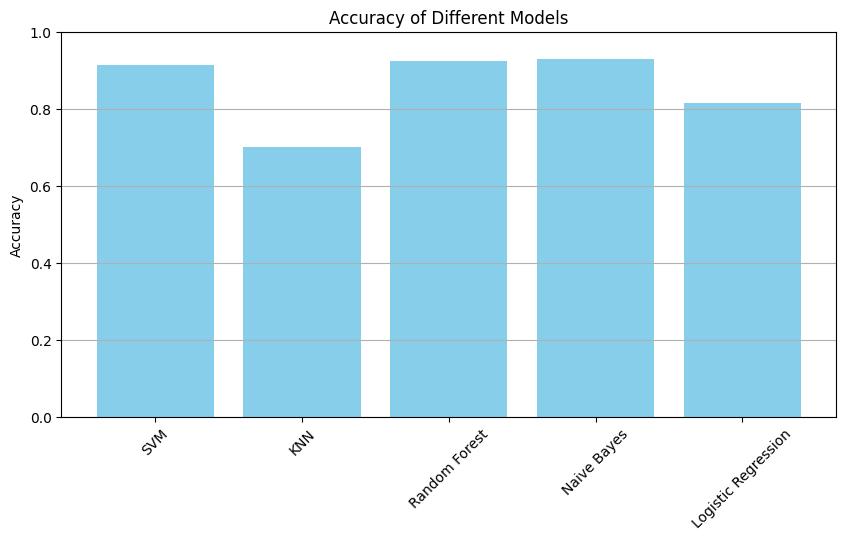

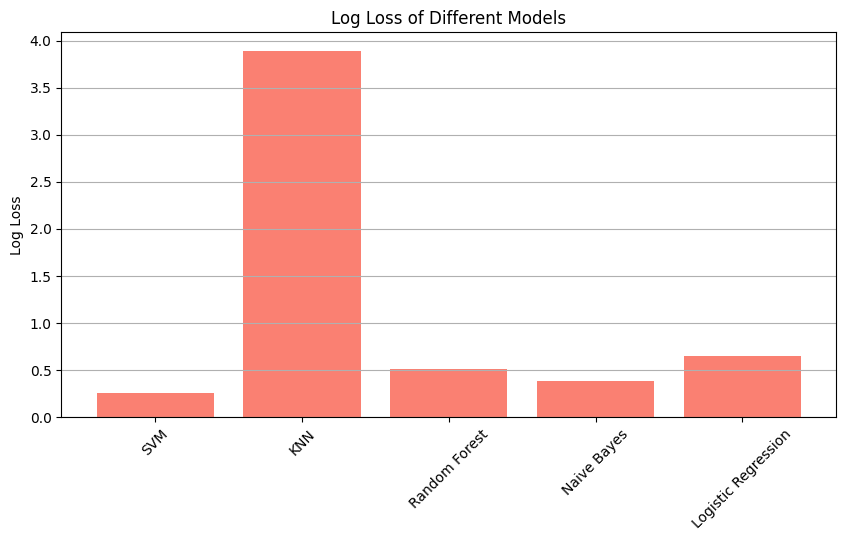

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, log_loss

# Define models with labels
models = {
    'SVM': SVC(C=10, gamma=0.01, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Random Forest': ensemble.RandomForestClassifier(n_estimators=300),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': linear_model.LogisticRegression(max_iter=1000)
}

accuracies = {}
losses = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    try:
        loss = log_loss(y_test, y_proba)
        losses[name] = loss
    except:
        losses[name] = None  # If log loss can't be calculated

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# Plot Loss (if available)
valid_losses = {k: v for k, v in losses.items() if v is not None}
if valid_losses:
    plt.figure(figsize=(10, 5))
    plt.bar(valid_losses.keys(), valid_losses.values(), color='salmon')
    plt.ylabel('Log Loss')
    plt.title('Log Loss of Different Models')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()
else:
    print("Log loss couldn't be calculated for the models.")
